# Análisis exploratorio de datos para el Stellar Classification Dataset - SDSS17
Saltemos directamente a un análisis general de los datos

## Descripción del dataset en Kaggle
### Context
In astronomy, stellar classification is the classification of stars based on their spectral characteristics. The classification scheme of galaxies, quasars, and stars is one of the most fundamental in astronomy. The early cataloguing of stars and their distribution in the sky has led to the understanding that they make up our own galaxy and, following the distinction that Andromeda was a separate galaxy to our own, numerous galaxies began to be surveyed as more powerful telescopes were built. This datasat aims to classificate stars, galaxies, and quasars based on their spectral characteristics.

### Content
The data consists of 100,000 observations of space taken by the SDSS (Sloan Digital Sky Survey). Every observation is described by 17 feature columns and 1 class column which identifies it to be either a star, galaxy or quasar.

1. obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
2. alpha = Right Ascension angle (at J2000 epoch)
3. delta = Declination angle (at J2000 epoch)
4. u = Ultraviolet filter in the photometric system
5. g = Green filter in the photometric system
6. r = Red filter in the photometric system
7. i = Near Infrared filter in the photometric system
8. z = Infrared filter in the photometric system
9. run_ID = Run Number used to identify the specific scan
10. rerun_ID = Rerun Number to specify how the image was processed
11. cam_col = Camera column to identify the scanline within the run
12. field_ID = Field number to identify each field
13. spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
14. class = object class (galaxy, star or quasar object)
15. redshift = redshift value based on the increase in wavelength
16. plate = plate ID, identifies each plate in SDSS
17. MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
18. fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [1]:
import numpy as np
import matplotlib as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('../dataset/star_classification.csv')

print("Primeras 5 filas del dataset:")
print(df.head())

print("\nInformación del dataset:")
print(df.info())

Primeras 5 filas del dataset:
         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354 

In [3]:
print("\nTamaño del dataset:")
print(df.shape)

print("\nEstadísticas descriptivas del dataset:")
print(df.describe())


Tamaño del dataset:
(100000, 18)

Estadísticas descriptivas del dataset:
             obj_ID          alpha          delta              u  \
count  1.000000e+05  100000.000000  100000.000000  100000.000000   
mean   1.237665e+18     177.629117      24.135305      21.980468   
std    8.438560e+12      96.502241      19.644665      31.769291   
min    1.237646e+18       0.005528     -18.785328   -9999.000000   
25%    1.237659e+18     127.518222       5.146771      20.352353   
50%    1.237663e+18     180.900700      23.645922      22.179135   
75%    1.237668e+18     233.895005      39.901550      23.687440   
max    1.237681e+18     359.999810      83.000519      32.781390   

                   g              r              i              z  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean       20.531387      19.645762      19.084854      18.668810   
std        31.750292       1.854760       1.757895      31.728152   
min     -9999.000000       9.822070  

In [4]:
print("\nNúmero de valores faltantes (todos):")
print(df.isna().sum())


Número de valores faltantes (todos):
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


## Exploratory Data Analysis (EDA)
A continuación realizaremos un análisis más profundo de las variables para entender su comportamiento.

### 1. Balance de Clases
Veamos cómo está distribuida nuestra variable objetivo (`class`)

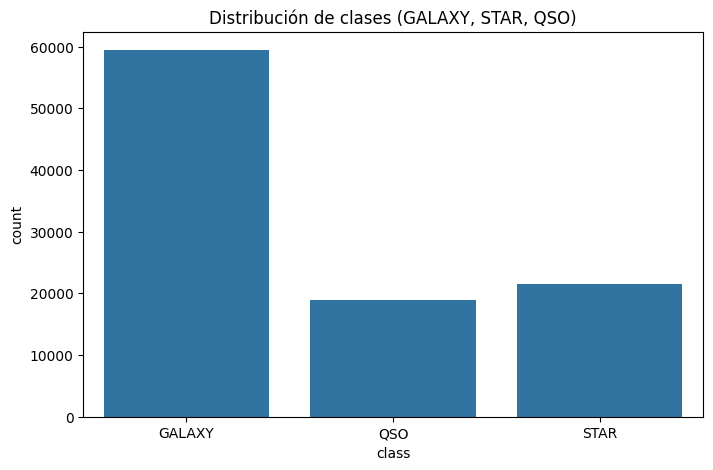

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df)
plt.title('Distribución de clases (GALAXY, STAR, QSO)')
plt.show()

### 2. Detección y tratamiento de anomalías
En las estadísticas descriptivas iniciales se observó que las características `u`, `g` y `z` (bandas fotométricas del ultravioleta, verde e infrarrojo) tienen un valor mínimo atípico de `-9999.0`, que es frecuentemente utilizado para codificar valores nulos o erróneos en estos catálogos astronómicos. Vamos a corroborar su existencia y eliminarlos.

In [6]:
# Cantidad de registros anómalos
anomalias = df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]
print(f"Cantidad de registros con valores -9999: {len(anomalias)}")

# Como es una cantidad ínfima (probablemente 1 observación), la eliminaremos del set.
df = df[(df['u'] != -9999) & (df['g'] != -9999) & (df['z'] != -9999)]
print(f"Nuevo tamaño del dataset sin anomalías: {df.shape}")

Cantidad de registros con valores -9999: 1
Nuevo tamaño del dataset sin anomalías: (99999, 18)


### 3. Distribución de características según la clase
Analizaremos cómo se distribuyen los principales parámetros fotométricos (filtros `u`, `g`, `r`, `i`, `z`) y el corrimiento al rojo (`redshift`) dependiendo del tipo de objeto.

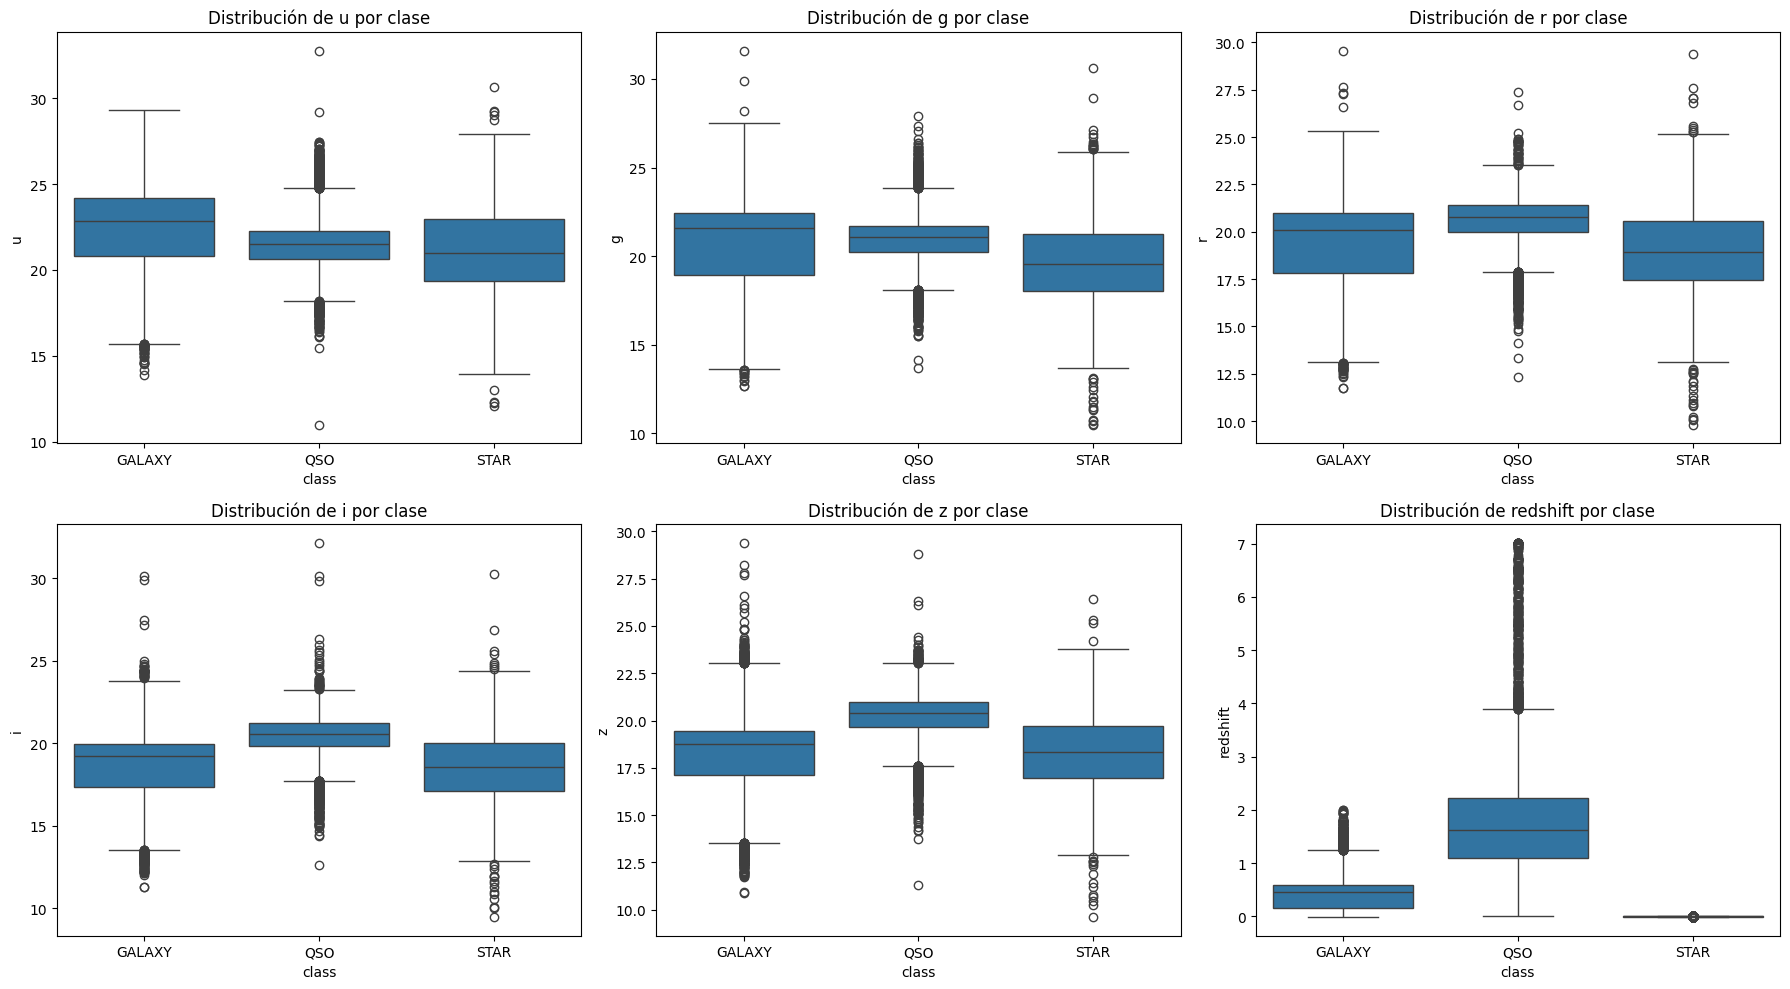

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features = ['u', 'g', 'r', 'i', 'z', 'redshift']

for i, ax in enumerate(axes.flatten()):
    sns.boxplot(x='class', y=features[i], data=df, ax=ax)
    ax.set_title(f'Distribución de {features[i]} por clase')

plt.tight_layout()
plt.show()

### 4. Análisis del Redshift por clase
El corrimiento al rojo (`redshift`) es un parámetro crucial en la astronomía para entender distancias. En el gráfico combinado anterior la resolución se pierde por los altos valores de los QSO. A continuación graficamos un histograma individual por cada clase para ganar resolución.

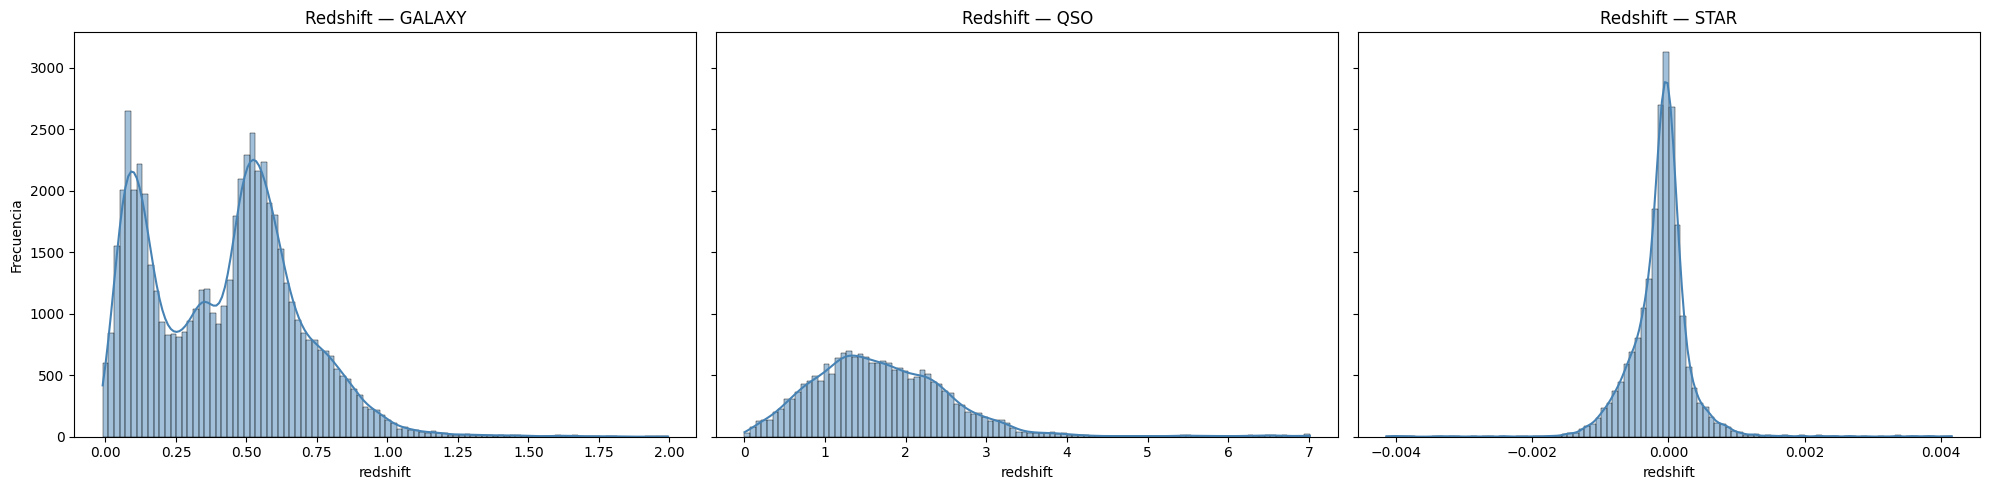

In [8]:
classes = df['class'].unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, cls in zip(axes, classes):
    subset = df[df['class'] == cls]
    sns.histplot(subset['redshift'], bins=100, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Redshift — {cls}')
    ax.set_xlabel('redshift')

axes[0].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### 5. Correlación de variables de importancia
Buscaremos identificar la redundancia en los filtros ('u', 'g', 'r', 'i', 'z') y la relación general con el resto de información.

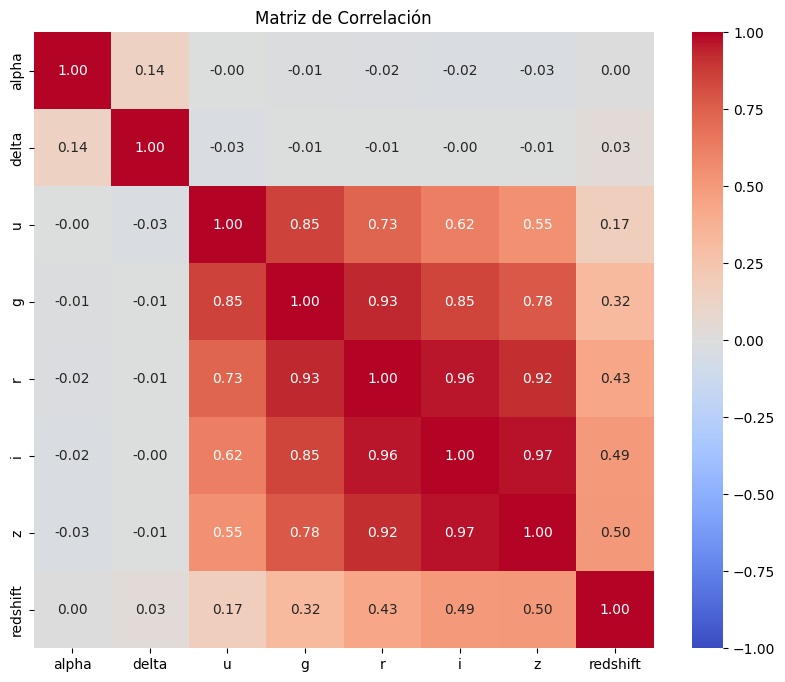

In [9]:
# Tomamos las variables físicas/ópticas que tienen sentido predictivo para una clasificación
features_num = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

plt.figure(figsize=(10, 8))
sns.heatmap(df[features_num].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

### 6. Distribución por clase de todas las variables numéricas
Así como hicimos con `redshift`, generamos una fila de 3 histogramas (uno por clase) para **cada** variable numérica. Esto permite ver el rango y la forma de cada distribución sin que una clase con valores extremos oculte el detalle de las demás.

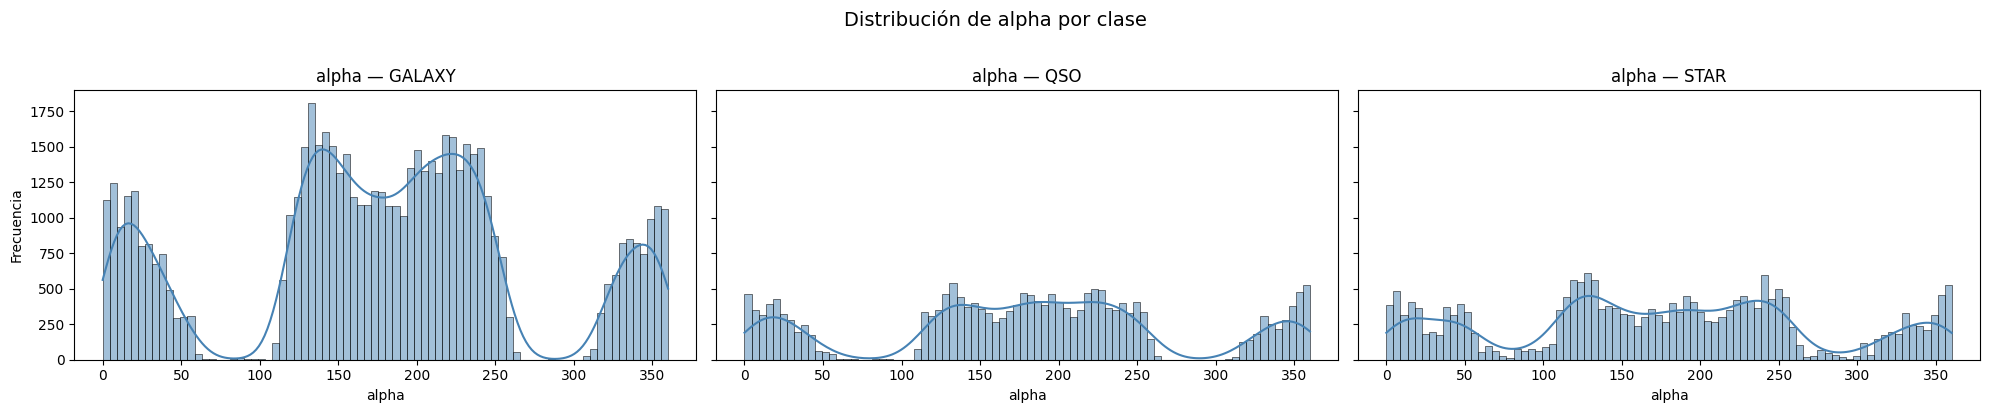

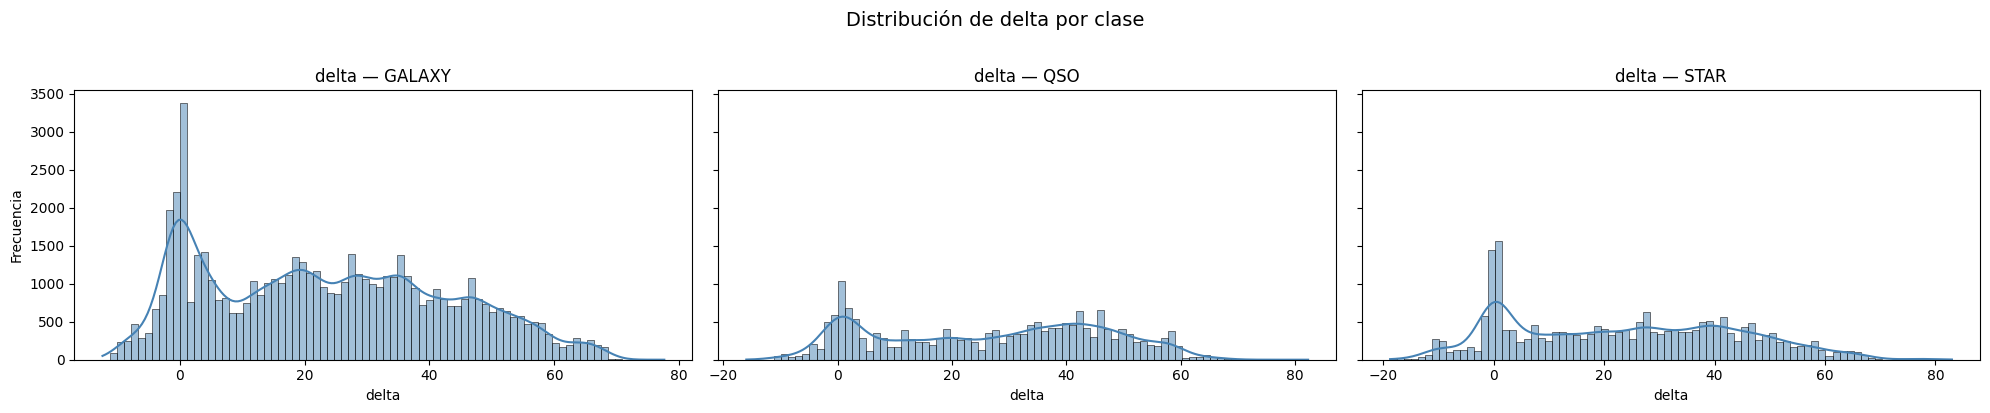

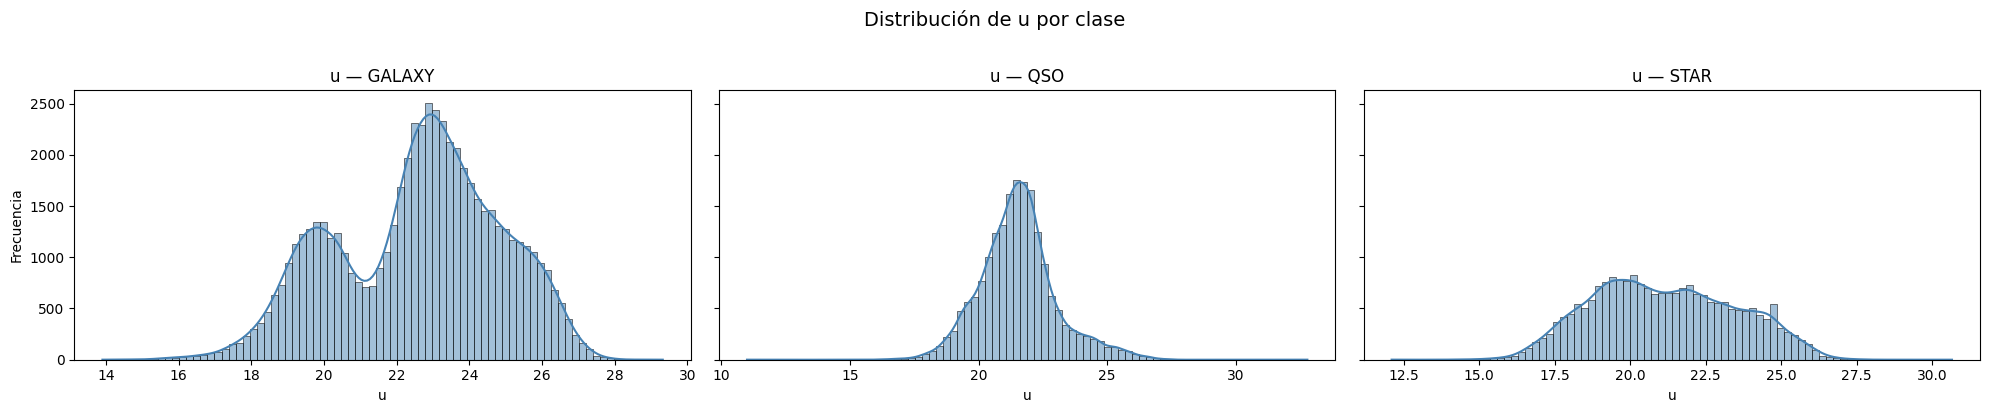

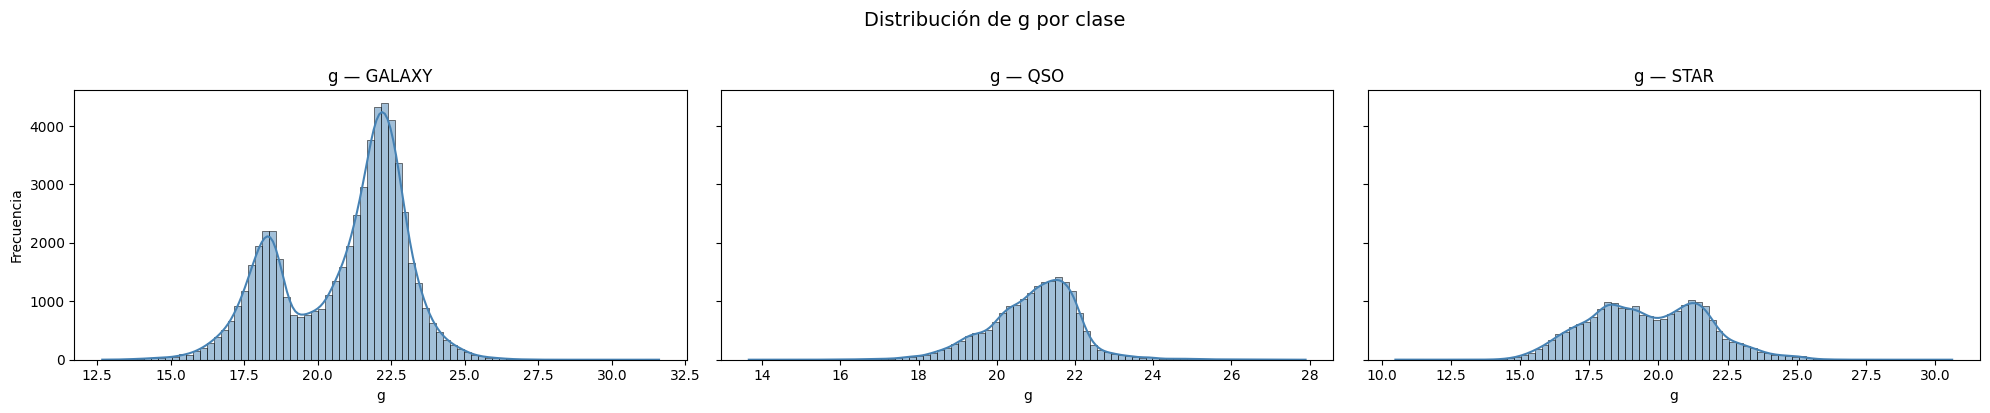

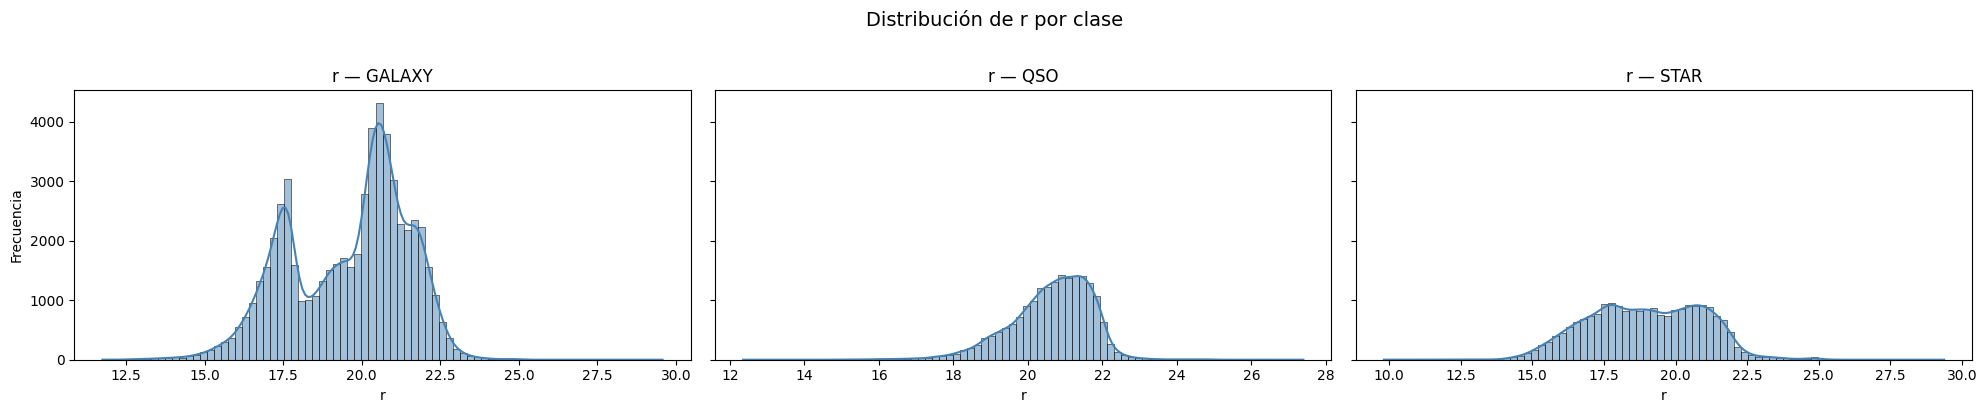

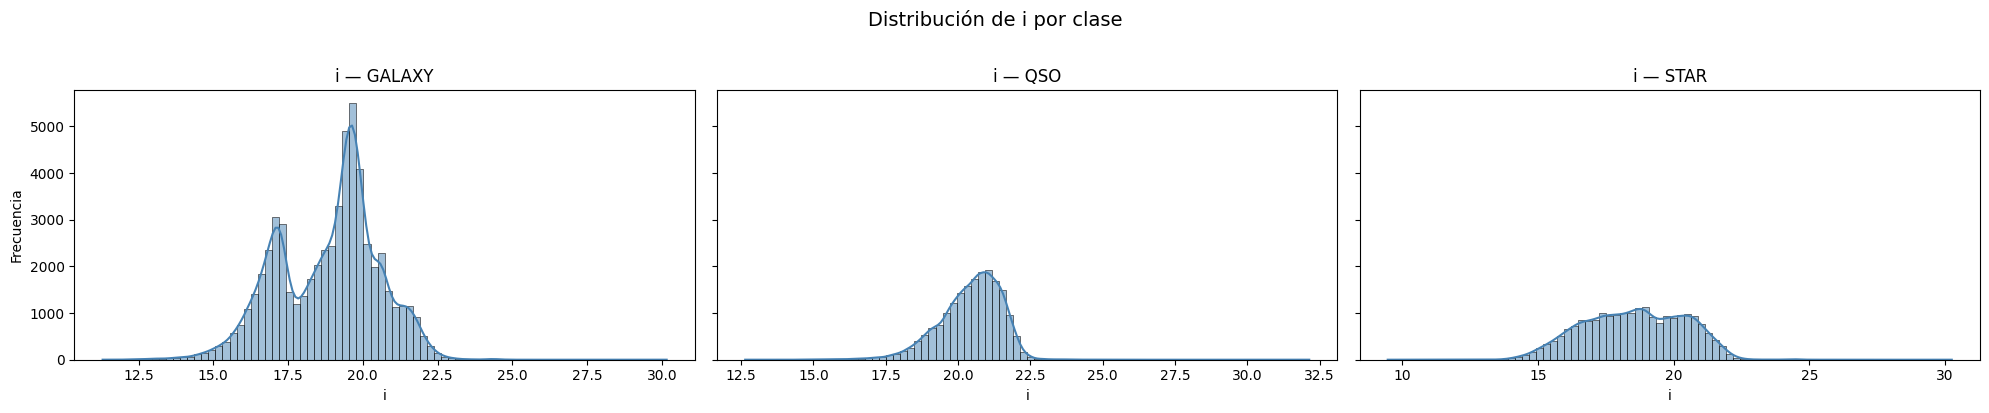

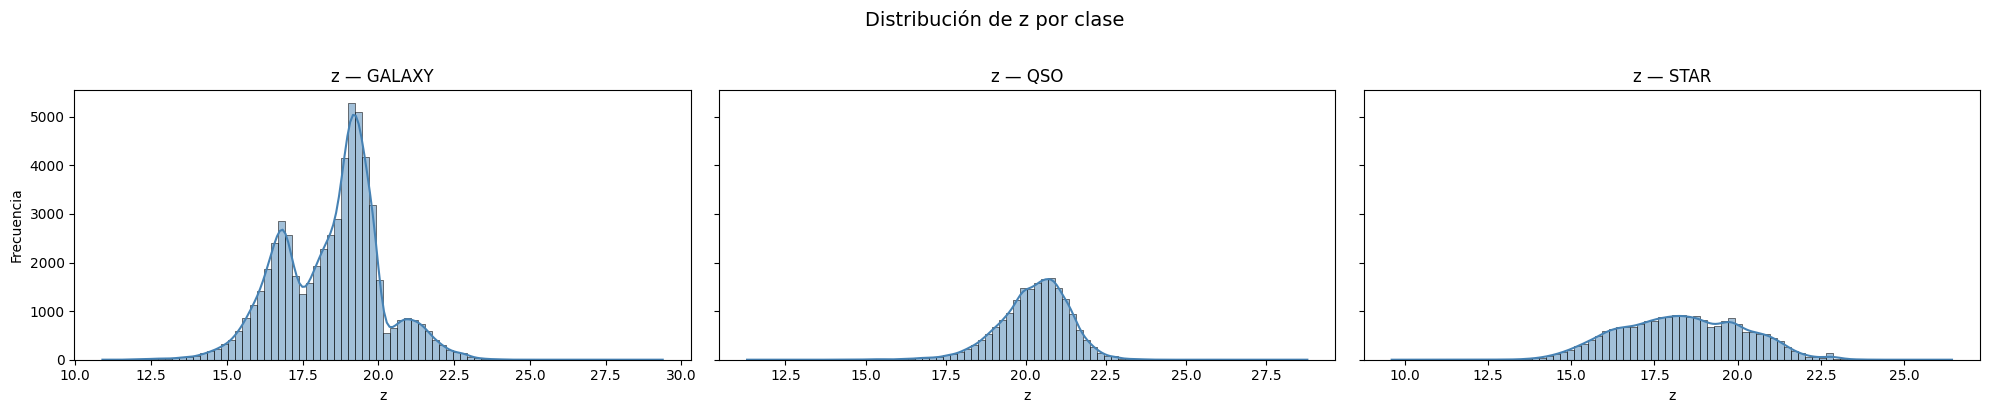

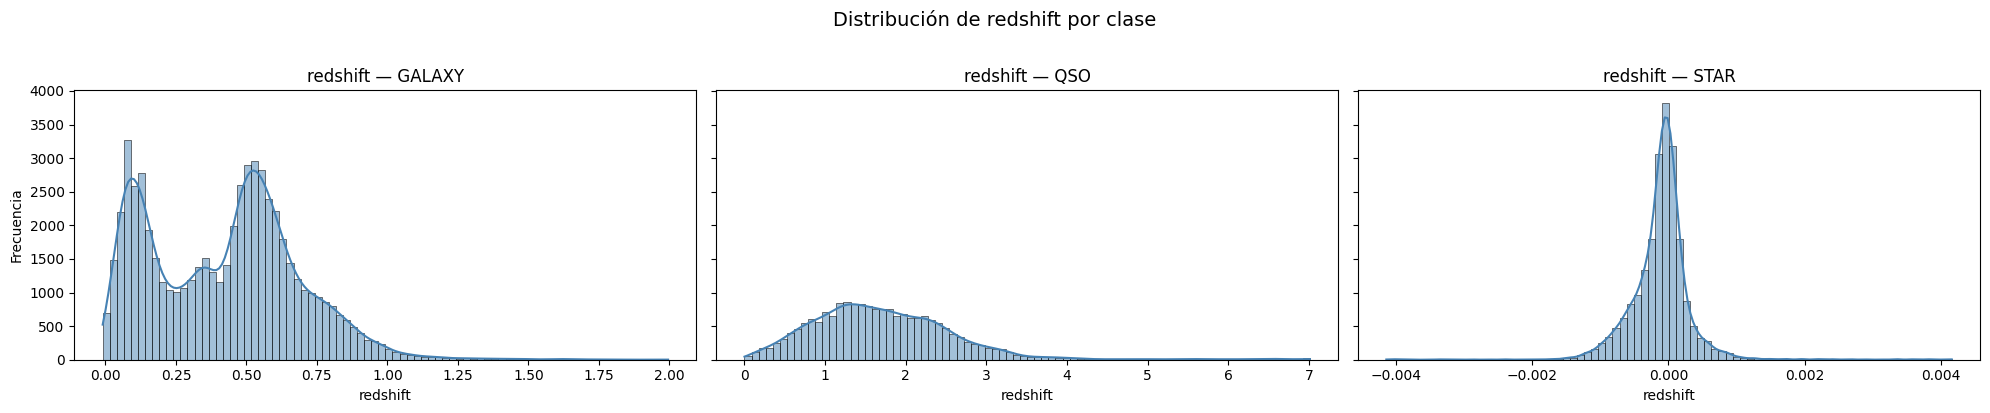

In [10]:
num_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
classes = df['class'].unique()

for feat in num_features:
    fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=True)
    for ax, cls in zip(axes, classes):
        subset = df[df['class'] == cls]
        sns.histplot(subset[feat], bins=80, kde=True, ax=ax, color='steelblue')
        ax.set_title(f'{feat} — {cls}')
        ax.set_xlabel(feat)
    axes[0].set_ylabel('Frecuencia')
    plt.suptitle(f'Distribución de {feat} por clase', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

### 7. Matriz de Correlación completa
Expandimos la matriz de correlación para incluir **todos** los features numéricos del dataset (incluidos los identificadores y las variables instrumentales). Esto permite detectar relaciones o redundancias que podrían no ser evidentes si solo se miran las variables físicas.

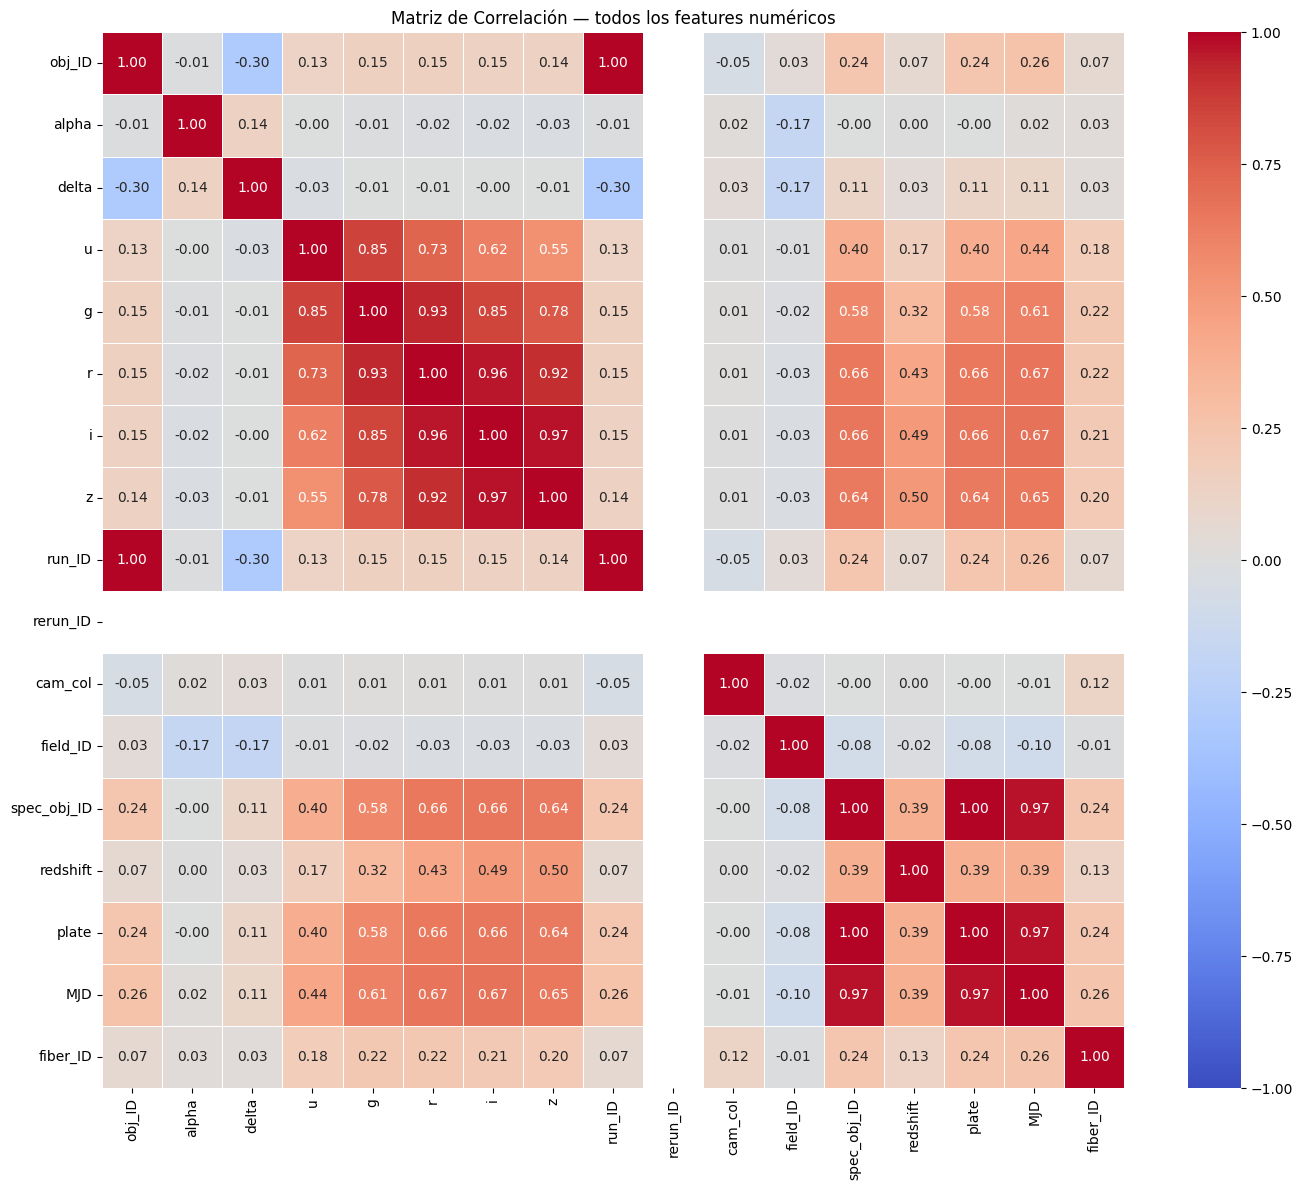

In [11]:
# Seleccionamos todas las columnas numéricas
all_num_cols = df.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(14, 12))
sns.heatmap(df[all_num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación — todos los features numéricos')
plt.tight_layout()


plt.show()

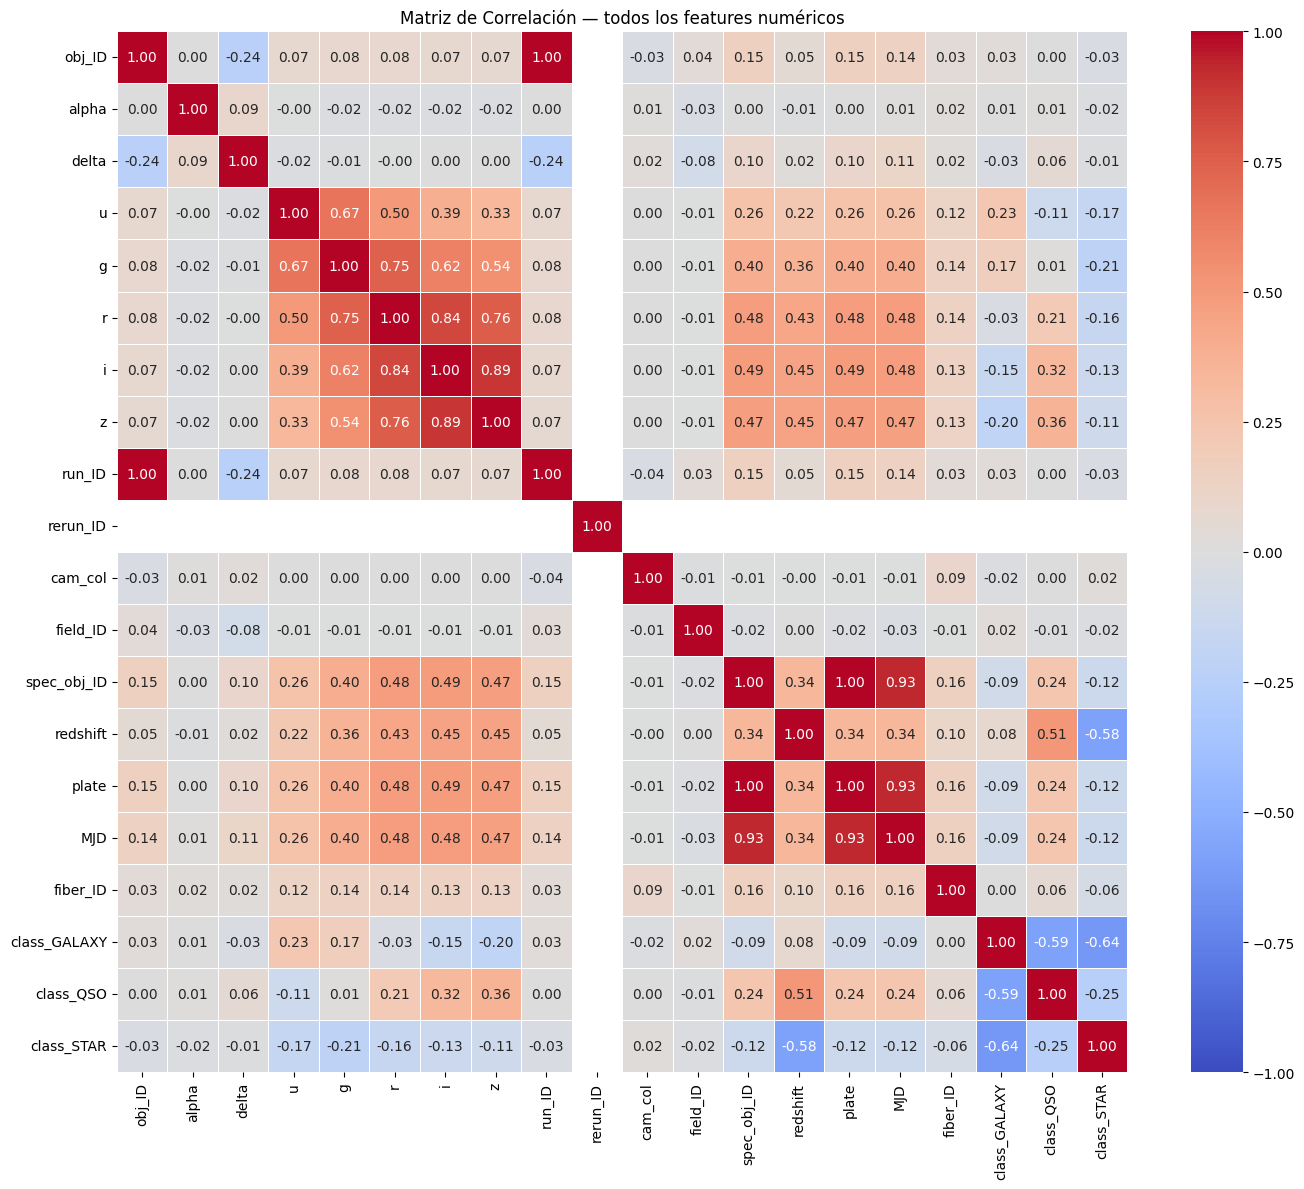

In [12]:
# Se aplica One-Hot Encoding a la columna clase para ver la correlación
df_dummies = pd.get_dummies(df, columns=['class'])

plt.figure(figsize=(14, 12))
sns.heatmap(df_dummies.corr(method="kendall"), annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación — todos los features numéricos')
plt.tight_layout()

### 8. Análisis de valores únicos por feature
Contamos la cantidad de valores únicos de cada columna. Esto sirve para:
- Detectar columnas de alta cardinalidad (como identificadores) que probablemente no aportan poder predictivo.
- Detectar columnas con muy pocos valores únicos (como `rerun_ID`, cuyo desvío estándar es 0) que podrían eliminarse directamente.
- Entender la naturaleza (continua vs. discreta) de cada feature.

In [13]:
unique_counts = df.nunique()
print('Valores únicos por columna:\n')
print(unique_counts.to_string())

Valores únicos por columna:

obj_ID         78052
alpha          99998
delta          99998
u              93747
g              92650
r              91900
i              92018
z              92006
run_ID           430
rerun_ID           1
cam_col            6
field_ID         856
spec_obj_ID    99999
class              3
redshift       99294
plate           6284
MJD             2180
fiber_ID        1000


### 9. Cantidad de outliers por feature numérico
Utilizamos el método del **rango intercuartílico (IQR)** para cuantificar los outliers en cada una de las variables `['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']`.

Un punto se considera outlier si cae por debajo de `Q1 - 1.5·IQR` o por encima de `Q3 + 1.5·IQR`.

          outliers  % del total
alpha            0         0.00
delta            0         0.00
u               55         0.06
g               98         0.10
r              132         0.13
i              198         0.20
z              319         0.32
redshift      8989         8.99


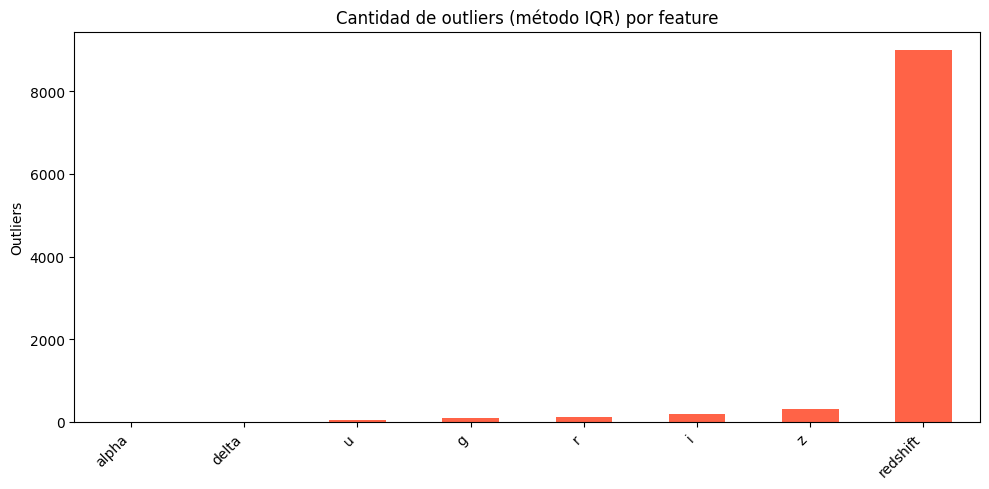

In [14]:
outlier_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
outlier_counts = {}

for feat in outlier_features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[feat] < lower) | (df[feat] > upper)).sum()
    outlier_counts[feat] = n_outliers

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['outliers'])
outlier_df['% del total'] = (outlier_df['outliers'] / len(df) * 100).round(2)
print(outlier_df.to_string())

# Gráfico
plt.figure(figsize=(10, 5))
outlier_df['outliers'].plot(kind='bar', color='tomato')
plt.title('Cantidad de outliers (método IQR) por feature')
plt.ylabel('Outliers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 10. Pair-plot de bandas fotométricas y redshift
Un *pair-plot* muestra scatter-plots entre cada par de variables y la distribución univariante en la diagonal, coloreados por clase. Es muy útil para:
- Evaluar visualmente la separabilidad entre clases.
- Detectar relaciones lineales/no lineales entre features.
- Confirmar patrones de correlación observados en la heatmap.

**Nota:** Se usa una muestra aleatoria de 5 000 puntos para que el gráfico se renderice rápidamente.

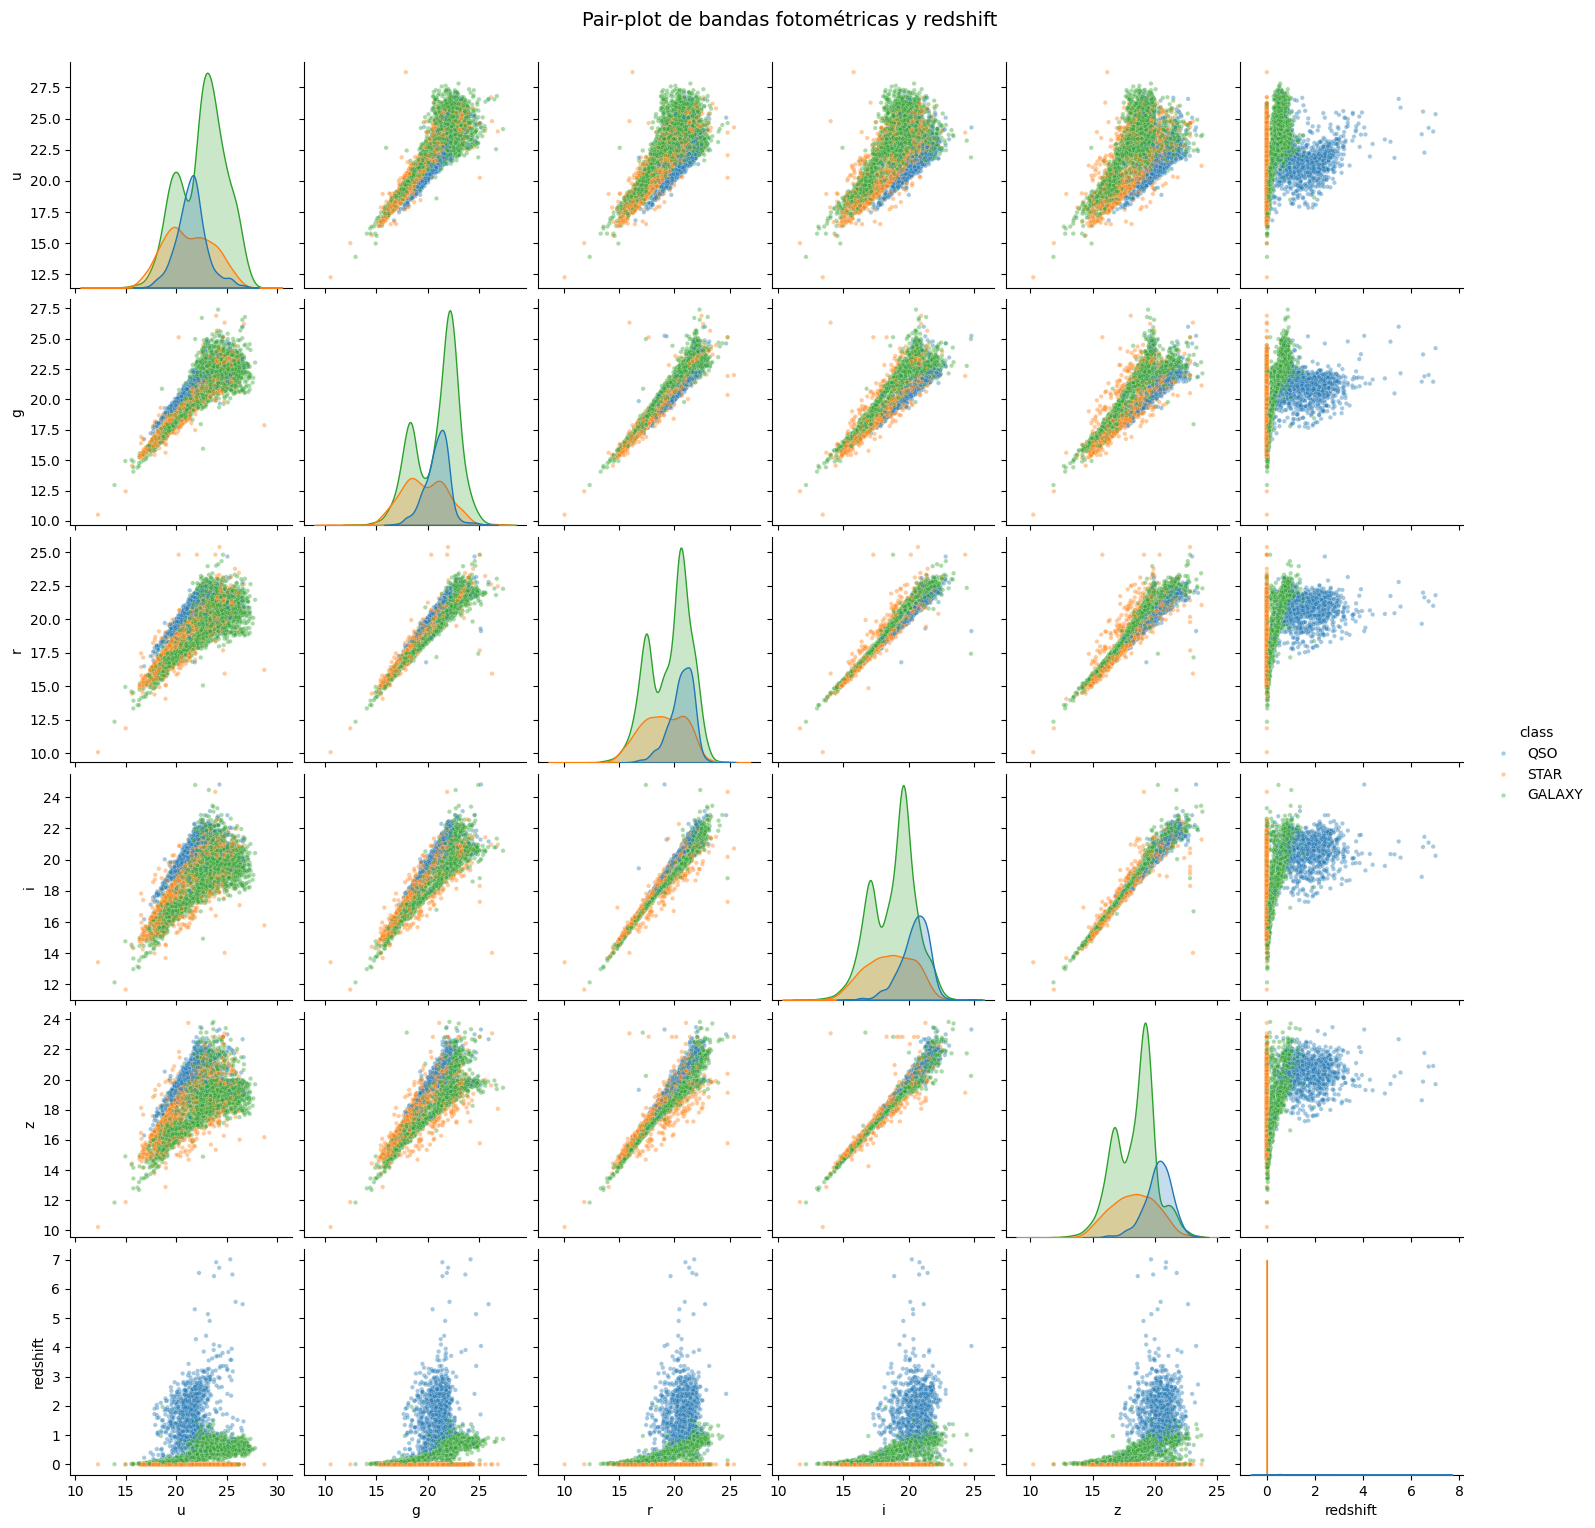

In [15]:
sample = df.sample(n=5000, random_state=42)
pairplot_vars = ['u', 'g', 'r', 'i', 'z', 'redshift']
sns.pairplot(sample, vars=pairplot_vars, hue='class', diag_kind='kde',
             plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle('Pair-plot de bandas fotométricas y redshift', y=1.02, fontsize=14)
plt.show()

### 11. Asimetría (skewness) y curtosis (kurtosis)
La *asimetría* mide cuánto se desvía la distribución de la simetría, y la *curtosis* mide qué tan pesadas son las colas en comparación con una distribución normal. Valores altos en cualquiera de las dos métricas sugieren distribuciones atípicas que podrían afectar el rendimiento de modelos lineales y es posible que requieran transformaciones (log, Box-Cox, etc.).

          skewness  kurtosis
alpha    -0.028498 -0.537205
delta     0.175064 -1.043054
u        -0.070298 -0.539040
g        -0.428037 -0.370721
r        -0.507880 -0.376138
i        -0.404183 -0.234843
z        -0.256822 -0.210003
redshift  2.523599  9.972864


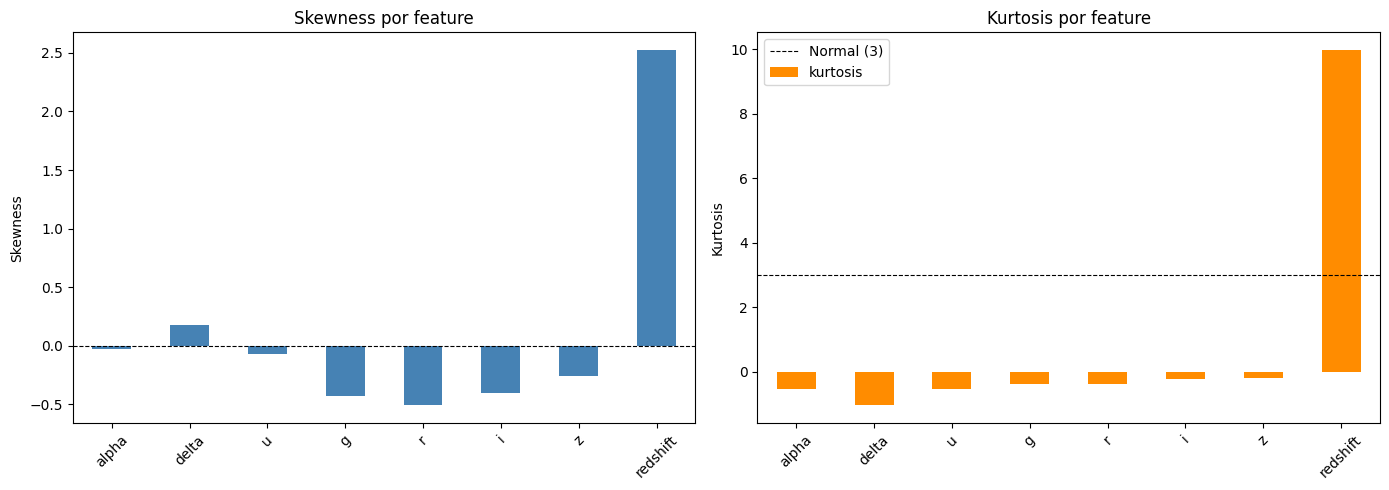

In [16]:
skew_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
skew_kurt = pd.DataFrame({
    'skewness': df[skew_features].skew(),
    'kurtosis': df[skew_features].kurt()
})
print(skew_kurt.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
skew_kurt['skewness'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Skewness por feature')
axes[0].set_ylabel('Skewness')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].tick_params(axis='x', rotation=45)

skew_kurt['kurtosis'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Kurtosis por feature')
axes[1].set_ylabel('Kurtosis')
axes[1].axhline(3, color='black', linewidth=0.8, linestyle='--', label='Normal (3)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 12. Importancia de features (Random Forest preliminar)
Entrenamos un Random Forest rápido para obtener un ranking de importancia de features. Esto nos da una primera idea de cuáles variables aportan más poder predictivo antes de pasar a la etapa formal de modelado.

Importancia de features (Random Forest):

redshift    0.618221
z           0.087193
i           0.074975
g           0.072070
u           0.070297
r           0.048104
alpha       0.014971
delta       0.014167


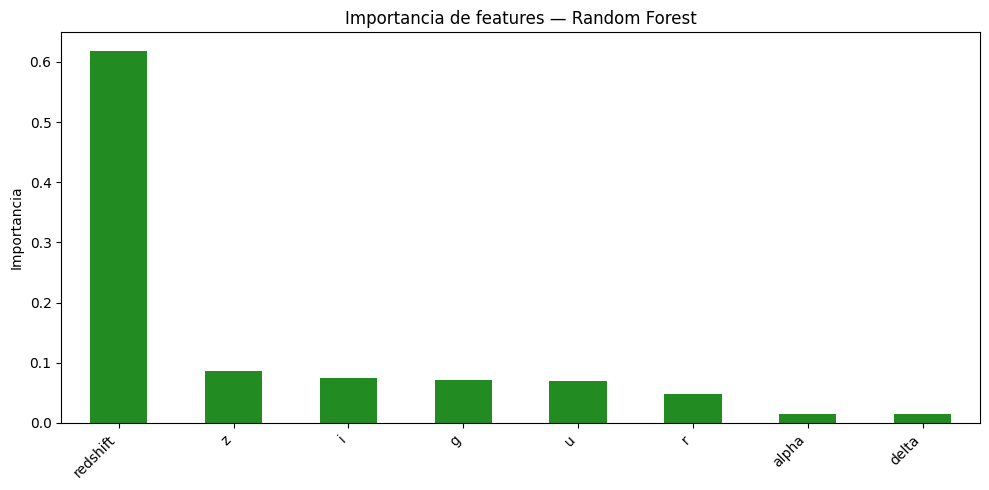

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Codificamos la clase
le = LabelEncoder()
y = le.fit_transform(df['class'])

# Features numéricos (excluyendo identificadores y la clase)
feat_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
X = df[feat_cols]

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
print('Importancia de features (Random Forest):\n')
print(importances.to_string())

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='forestgreen')
plt.title('Importancia de features — Random Forest')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Baseline classifier
Se arma una especie de clasificación deducida a partir de los gráficos, para usar como baseline de comparación con los demás modelos.

El feature con mayor poder descriptivo parece ser `redshift`, por lo cual lo analizaremos un poco más en detalle para el dataset, separado por clase, con el objetivo de usarlo para definir el baseline.

In [59]:
df[df['class'] == 'GALAXY']['redshift'].describe()

count    59445.000000
mean         0.421596
std          0.264858
min         -0.009971
25%          0.164527
50%          0.456274
75%          0.594699
max          1.995524
Name: redshift, dtype: float64

In [60]:
df[df['class'] == 'STAR']['redshift'].describe()

count    21593.000000
mean        -0.000115
std          0.000465
min         -0.004136
25%         -0.000295
50%         -0.000076
75%          0.000075
max          0.004153
Name: redshift, dtype: float64

In [62]:
df[df['class'] == 'QSO']['redshift'].describe()

count    18961.000000
mean         1.719676
std          0.913954
min          0.000461
25%          1.106605
50%          1.617232
75%          2.220279
max          7.011245
Name: redshift, dtype: float64

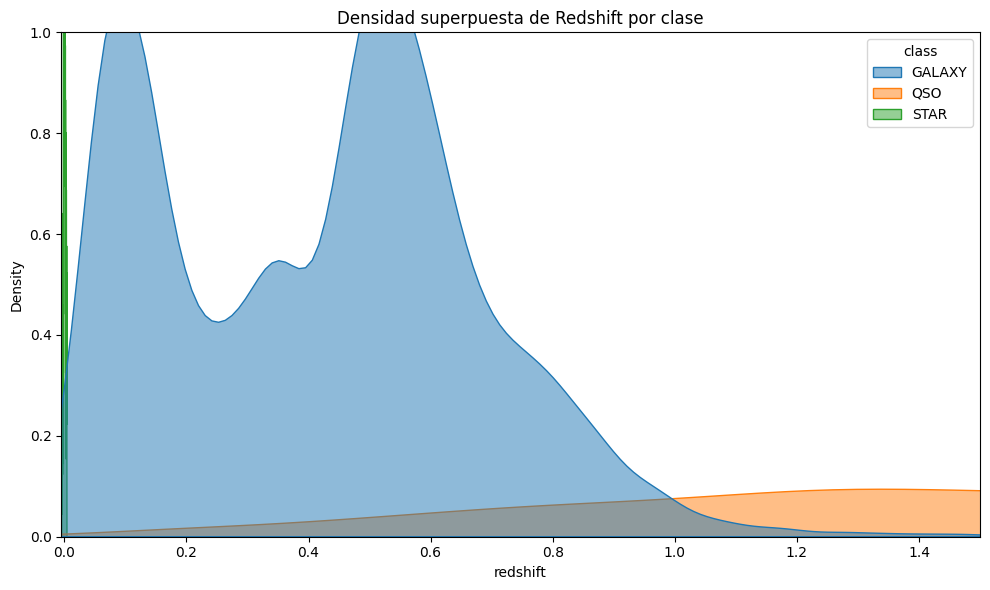

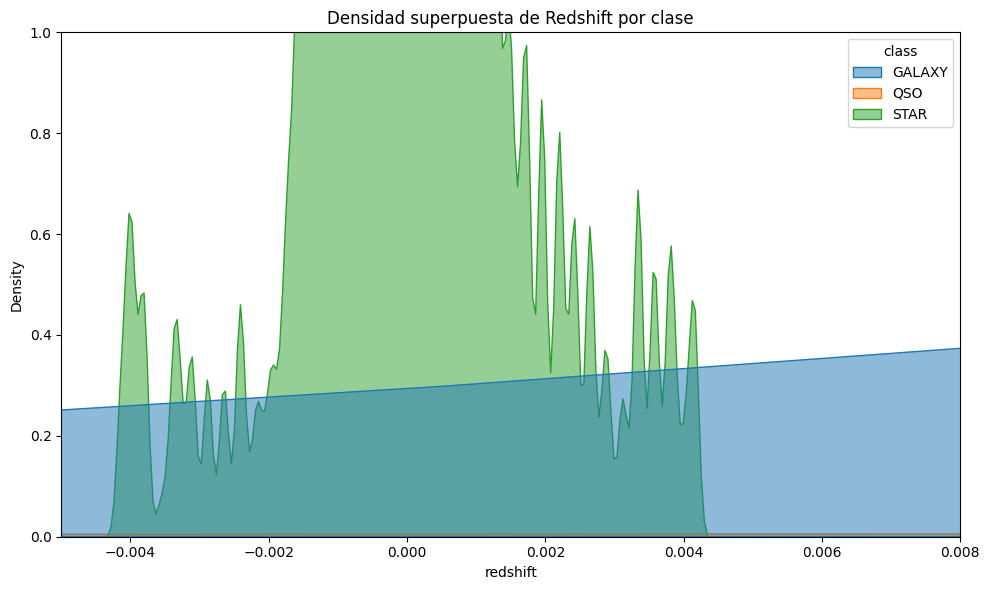

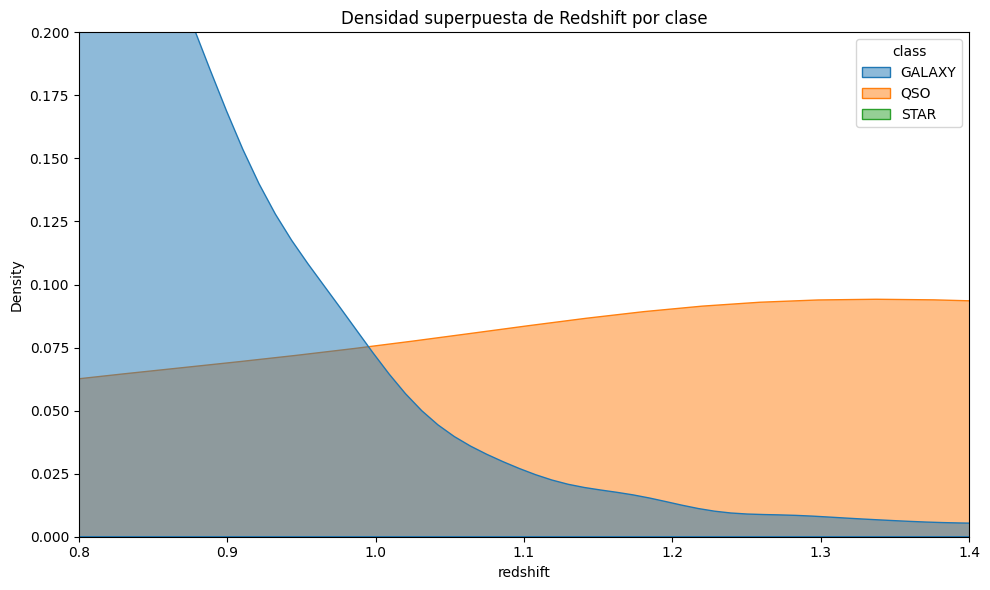

In [58]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='redshift',
    hue='class',
    fill=True,
    alpha=0.5,
)
plt.title('Densidad superpuesta de Redshift por clase')

plt.xlim(-0.005, 1.5)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='redshift',
    hue='class',
    fill=True,
    alpha=0.5,
)
plt.title('Densidad superpuesta de Redshift por clase')

plt.xlim(-0.005, 0.008)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='redshift',
    hue='class',
    fill=True,
    alpha=0.5,
)
plt.title('Densidad superpuesta de Redshift por clase')

plt.xlim(0.8, 1.4)
plt.ylim(0, 0.2)
plt.tight_layout()
plt.show()

Observando estos tres gráficos podemos definir los siguientes límites para sobre el Redshift:
- $Redshift \leq 0.0045$ $\implies$ STAR
- $0.0045 < Redshift \leq 1.0$ $\implies$ GALAXY
- $1.0 < Redshift$ $\implies$ QSO

Hagamos una prueba sobre todo el dataset para ver el porcentaje de aciertos obtenido.

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

Reporte de clasificación del baseline
              precision    recall  f1-score   support

      GALAXY       0.94      0.98      0.96     59445
         QSO       0.94      0.80      0.86     18961
        STAR       0.98      1.00      0.99     21593

    accuracy                           0.95     99999
   macro avg       0.95      0.92      0.94     99999
weighted avg       0.95      0.95      0.95     99999



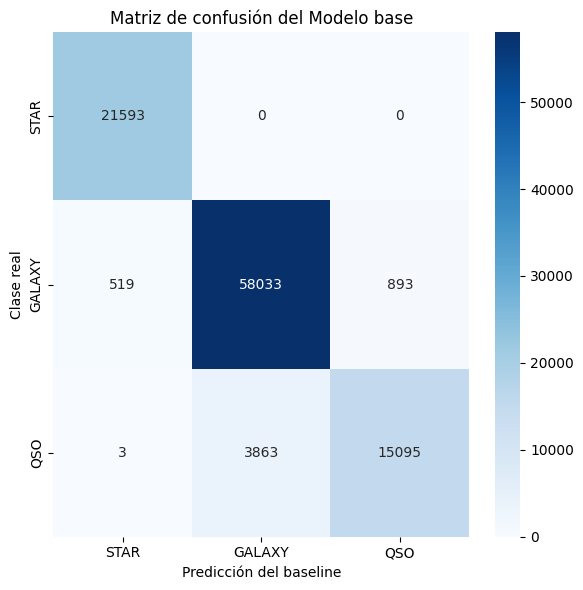

In [67]:
cortes = [-np.inf, 0.0045, 1.0, np.inf]
etiquetas = ['STAR', 'GALAXY', 'QSO']

# El método cut() incluye por defecto el <= en los bordes derechos
df['baseline_pred'] = pd.cut(df['redshift'], bins=cortes, labels=etiquetas)

print("Reporte de clasificación del baseline")
print(classification_report(df['class'], df['baseline_pred']))

cm = confusion_matrix(df['class'], df['baseline_pred'], labels=etiquetas)
plt.figure(figsize=(6, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=etiquetas, yticklabels=etiquetas
)
plt.xlabel('Predicción del baseline')
plt.ylabel('Clase real')
plt.title('Matriz de confusión del Modelo base')
plt.tight_layout()
plt.show()